Model - Val Accuracy - Epochs

Dense - 84.11 - 2

Dense_Improve - 87.06 - 3

CNN - 89.35 - 3

CNN_Improve - 89.79 - 2

RNN - 81.00 - 4

RNN_Improve - 84.37 - 4

LSTM - 84.47 - 2

LSTM_Improve - 85.04 - 3

In [ ]:
import keras
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding
from keras.layers import SpatialDropout1D, Conv1D, GlobalMaxPooling1D
from keras.layers import LSTM
from keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# output directory name:
output_dir = 'model_output/LSTM'

# training:
epochs = 4
batch_size = 128

# vector-space embedding:
n_dim = 64
n_unique_words = 10000
max_review_length = 100
pad_type = trunc_type = 'pre'
drop_embed = 0.2

# LSTM layer architecture:
n_lstm = 256
drop_lstm = 0.2

# dense layer architecture:
# n_dense = 256
# dropout = 0.2

In [ ]:
(x_train, y_train), (x_valid, y_valid) = imdb.load_data(num_words=n_unique_words) # removed n_words_to_skip

x_train = pad_sequences(x_train, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)
x_valid = pad_sequences(x_valid, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential()

# 1st hidden Layer
model.add(Embedding(input_dim=n_unique_words, output_dim=n_dim, input_shape=(max_review_length,)))
model.add(SpatialDropout1D(drop_embed))

# 2nd hidden layer
model.add(LSTM(n_lstm, dropout=drop_lstm))

# Output layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 968,961 (3.70 MB)

 Trainable params: 968,961 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

modelcheckpoint = ModelCheckpoint(filepath=output_dir+"/model_epoch_{epoch:02d}.keras")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_valid, y_valid), callbacks=[modelcheckpoint])

Epoch 1/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7265 - loss: 0.5117 - val_accuracy: 0.8407 - val_loss: 0.3718
Epoch 2/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8746 - loss: 0.3019 - val_accuracy: 0.8447 - val_loss: 0.3598
Epoch 3/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9039 - loss: 0.2509 - val_accuracy: 0.8457 - val_loss: 0.3790
Epoch 4/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9240 - loss: 0.1987 - val_accuracy: 0.8465 - val_loss: 0.3700


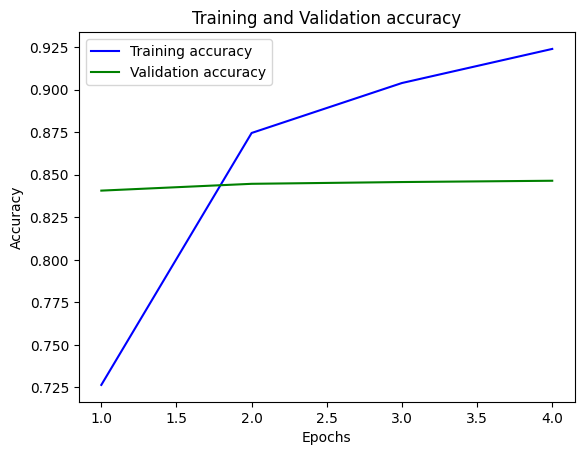

In [ ]:
loss_train = history.history['accuracy']
loss_val = history.history['val_accuracy']
epochs = range(1, 5) # range end will be epoch + 1
plt.plot(epochs, loss_train, 'b', label='Training accuracy')
plt.plot(epochs, loss_val, 'g', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


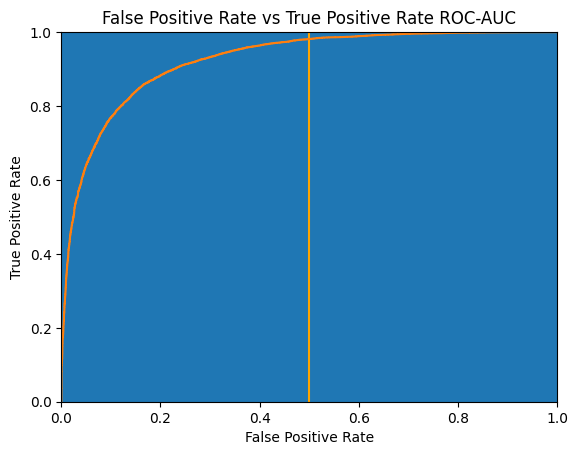

In [ ]:
model.load_weights(output_dir+"/model_epoch_02.keras")

y_hat = model.predict(x_valid)

plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')

# ROC-AUC Score
"{:0.2f}".format(roc_auc_score(y_valid, y_hat)*100.0)

# ROC Curve
fpr , tpr , thresholds = roc_curve (y_valid , y_hat)
plt.plot(fpr,tpr)
plt.axis([0,1,0,1])
plt.title('False Positive Rate vs True Positive Rate ROC-AUC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
n_lstm_imp = 512
drop_lstm_imp = 0.3
learning_rate_imp = 0.001
epochs_imp = 6

output_dir_imp = 'model_output/LSTM_Improved'

In [ ]:
model_imp = Sequential()

model_imp.add(Embedding(input_dim=n_unique_words, output_dim=n_dim, input_shape=(max_review_length,)))
model_imp.add(SpatialDropout1D(drop_embed))

model_imp.add(LSTM(n_lstm_imp, dropout=drop_lstm_imp))

model_imp.add(Dense(1, activation='sigmoid'))
model_imp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 512)            │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,822,209 (6.95 MB)

 Trainable params: 1,822,209 (6.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_imp.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

if not os.path.exists(output_dir_imp):
    os.makedirs(output_dir_imp)

checkpoint_imp = ModelCheckpoint(filepath=output_dir_imp+"/improved_epoch_{epoch:02d}.keras")

history_imp = model_imp.fit(x_train, y_train,
                            batch_size=batch_size,
                            epochs=epochs_imp,
                            validation_data=(x_valid, y_valid),
                            callbacks=[checkpoint_imp])

Epoch 1/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.6661 - loss: 0.5940 - val_accuracy: 0.8312 - val_loss: 0.3792
Epoch 2/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.8595 - loss: 0.3339 - val_accuracy: 0.8452 - val_loss: 0.3545
Epoch 3/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.8926 - loss: 0.2712 - val_accuracy: 0.8504 - val_loss: 0.3468
Epoch 4/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9128 - loss: 0.2260 - val_accuracy: 0.8452 - val_loss: 0.3598
Epoch 5/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9268 - loss: 0.1947 - val_accuracy: 0.8389 - val_loss: 0.4486
Epoch 6/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9365 - loss: 0.1707 - val_accuracy: 0.8424 - val_loss: 0.4063
